![tasks](../docs/tasks.png)


# Random Forestモデルの構築

In [1]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree

import graphviz
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
x_train = pd.read_csv('../data/treated-data/task2/df_x_train.csv')
y_train = pd.read_csv('../data/treated-data/task2/df_y_train.csv')
x_test = pd.read_csv('../data/treated-data/task2/df_x_test.csv')
y_test = pd.read_csv('../data/treated-data/task2/df_y_test.csv')

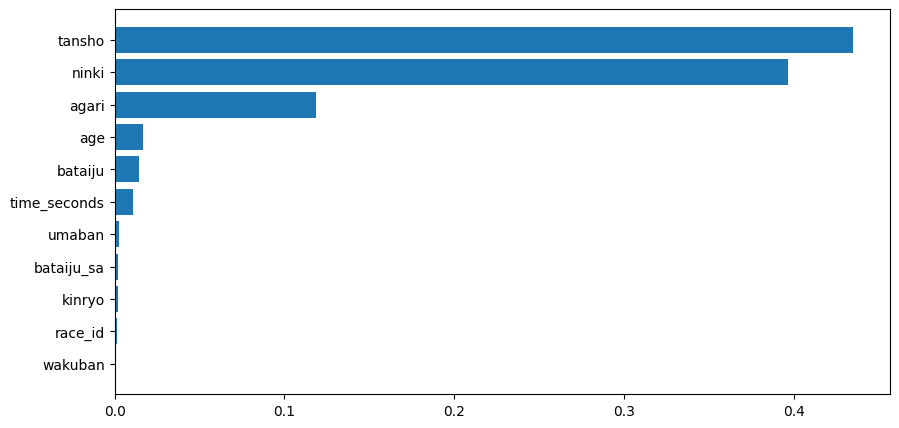

In [3]:
rf_model = RandomForestClassifier(random_state=0, max_depth=3, n_estimators=150)
rf_model = rf_model.fit(x_train, y_train)

features = x_train.columns
importances = rf_model.feature_importances_
indices = np.argsort(importances)

#重要度を降順に並び替え横棒プロットする
plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.show()

In [6]:
# SHAP値の計算（interventionalモードを明示的に指定してエラー回避）
explainer = shap.TreeExplainer(rf_model, x_train, feature_perturbation="interventional")
# 少数のサンプルで計算したい場合: 例えば最初の100件だけに限定
shap_values = explainer.shap_values(x_test.iloc[:100], check_additivity=False)

In [7]:
rf_model.predict_proba(x_test)[0]

array([0.0266579 , 0.08815983, 0.88518227])

## Tree SHAPでの当てはめ

In [8]:
explainer_tree = shap.TreeExplainer(rf_model, x_test)
shap_values_tree = explainer_tree.shap_values(x_test, check_additivity=False)

 93%|=================== | 15665/16797 [00:11<00:00]       

In [12]:
shap.initjs()

display(shap.force_plot(explainer_tree.expected_value[0], shap_values_tree[0][:, 0], x_test.iloc[0, :]))
display(shap.force_plot(explainer_tree.expected_value[0], shap_values_tree[0][:, 1], x_test.iloc[0, :]))
display(shap.force_plot(explainer_tree.expected_value[0], shap_values_tree[0][:, 2], x_test.iloc[0, :]))

In [18]:
def plot_shap_summary_multiclass_rf(model, X, class_names=None, max_display=20):
    """
    model: sklearn RandomForestClassifier (学習済み)
    X: pandas.DataFrame 推奨（feature_namesが綺麗に出る）
    class_names: ["Class 0","Class 1","Class 2"] など（省略可）
    """
    # 1) Explainer（RFはTreeExplainer系が効く）
    explainer = shap.Explainer(model, X)      # shap.TreeExplainer(model) でもOK
    sv = explainer(X)                         # 新形式: shap.Explanation が返ることが多い

    # 2) 返り値の形式差を吸収して「クラス別の (n, f) 行列」を取り出す
    # --- 新形式 (Explanation): values が (n, f, c) または (n, c, f)
    if hasattr(sv, "values"):
        vals = np.array(sv.values)
        Xv = np.array(sv.data) if hasattr(sv, "data") else np.array(X)

        if vals.ndim == 3:
            n, f = Xv.shape
            # (n, f, c) か (n, c, f) を判定
            if vals.shape[1] == f:
                # (n, f, c)
                n_classes = vals.shape[2]
                get_sv = lambda k: vals[:, :, k]
            else:
                # (n, c, f)
                n_classes = vals.shape[1]
                get_sv = lambda k: vals[:, k, :]
        else:
            raise ValueError(f"Unexpected sv.values shape: {vals.shape}")

    # --- 旧形式: shap_values が [class0_array, class1_array, class2_array]
    else:
        # 念のため
        vals = sv
        n_classes = len(vals)
        Xv = np.array(X)
        get_sv = lambda k: np.array(vals[k])

    # 3) class_names の補完
    if class_names is None:
        class_names = [f"Class {i}" for i in range(n_classes)]

    # 4) クラスごとに summary_plot
    for k in range(n_classes):
        plt.figure()
        shap.summary_plot(
            get_sv(k), X,  # XはDataFrameのまま渡すと名前が綺麗
            plot_type="dot",
            max_display=max_display,
            show=False
        )
        plt.title(class_names[k])
        plt.show()

 98%|===================| 16507/16797 [00:12<00:00]        

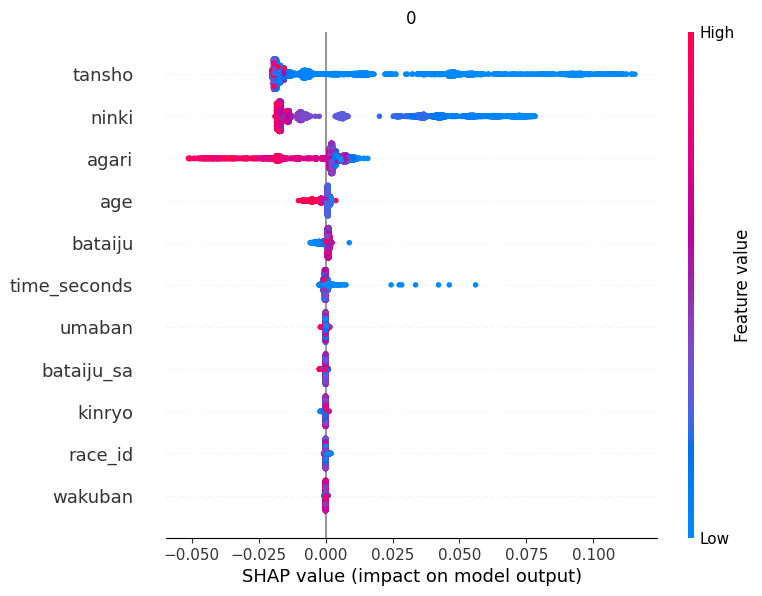

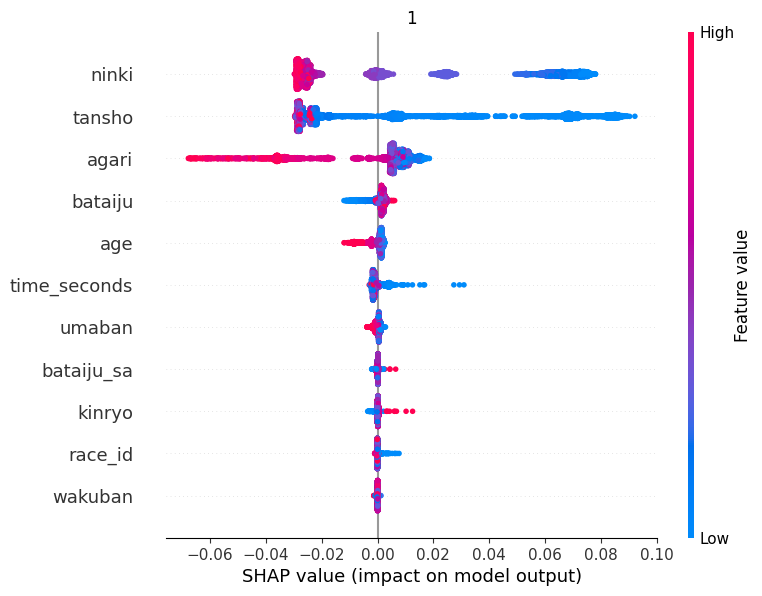

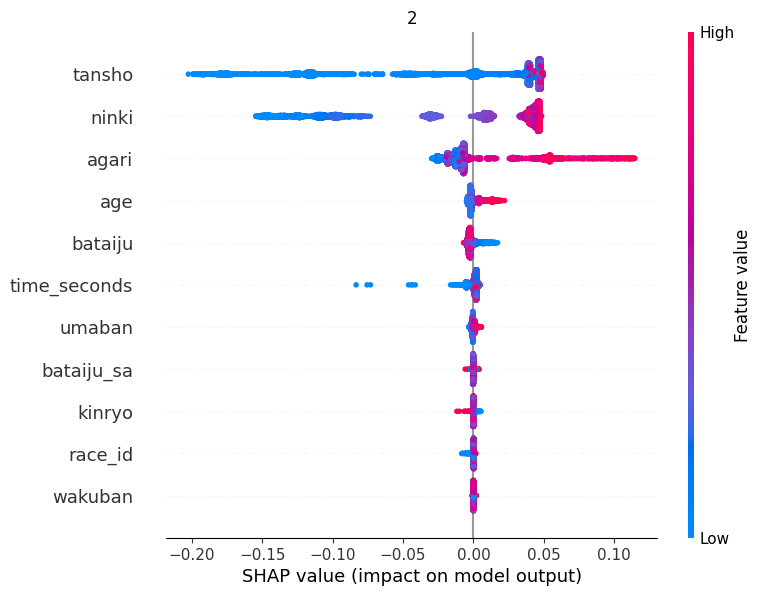

In [19]:
plot_shap_summary_multiclass_rf(rf_model, x_test, class_names=[0,1,2])